In [1]:
# 📌 Import libraries
import pandas as pd
import numpy as np
from scipy import stats

# 🔗 Load CSV from GitHub
url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

# ✅ Display first records
print("First 5 records of dataset:")
df.head()


First 5 records of dataset:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
print("Numerical Columns:\n", df.select_dtypes(include=np.number).columns)
print("\nCategorical Columns:\n", df.select_dtypes(include='object').columns)


Numerical Columns:
 Index(['math score', 'reading score', 'writing score'], dtype='str')

Categorical Columns:
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='str')


C:\Users\Bhavya\AppData\Local\Temp\ipykernel_30672\3630851249.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("\nCategorical Columns:\n", df.select_dtypes(include='object').columns)


In [3]:
# Choose numerical columns for analysis
num_cols = ['math score','reading score','writing score']

# Mean
mean_vals = df[num_cols].mean()
print("\nMean:\n", mean_vals)

# Median
median_vals = df[num_cols].median()
print("\nMedian:\n", median_vals)

# Mode
mode_vals = df[num_cols].mode().iloc[0]
print("\nMode:\n", mode_vals)



Mean:
 math score       66.089
reading score    69.169
writing score    68.054
dtype: float64

Median:
 math score       66.0
reading score    70.0
writing score    69.0
dtype: float64

Mode:
 math score       65
reading score    72
writing score    74
Name: 0, dtype: int64


In [4]:
dispersion = {
    'Minimum': df[num_cols].min(),
    'Maximum': df[num_cols].max(),
    'Sum': df[num_cols].sum(),
    'Variance': df[num_cols].var(),
    'Std Deviation': df[num_cols].std()
}
dispersion_df = pd.DataFrame(dispersion)
print("\nDispersion Stats:\n", dispersion_df)



Dispersion Stats:
                Minimum  Maximum    Sum    Variance  Std Deviation
math score           0      100  66089  229.918998      15.163080
reading score       17      100  69169  213.165605      14.600192
writing score       10      100  68054  230.907992      15.195657


In [5]:
# Calculate quartiles
quartiles = df[num_cols].quantile([0.25, 0.5, 0.75]).rename(index={0.25:'Q1',0.5:'Median',0.75:'Q3'})
print("Quartiles (Q1, Q2, Q3):\n", quartiles)


Quartiles (Q1, Q2, Q3):
         math score  reading score  writing score
Q1            57.0           59.0          57.75
Median        66.0           70.0          69.00
Q3            77.0           79.0          79.00


In [6]:
# Correlation matrix
corr_matrix = df[num_cols].corr()
print("Correlation Matrix:\n", corr_matrix)


Correlation Matrix:
                math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


In [7]:
cov_matrix = df[num_cols].cov()
print("Covariance Matrix:\n", cov_matrix)


Covariance Matrix:
                math score  reading score  writing score
math score     229.918998     180.998958     184.939133
reading score  180.998958     213.165605     211.786661
writing score  184.939133     211.786661     230.907992


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set theme
sns.set(style="whitegrid")

# 🔹 Histograms
plt.figure(figsize=(15,5))
for i, col in enumerate(num_cols,1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram: {col}")
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'seaborn'

In [9]:
!pip install seaborn


'pip' is not recognized as an internal or external command,
operable program or batch file.


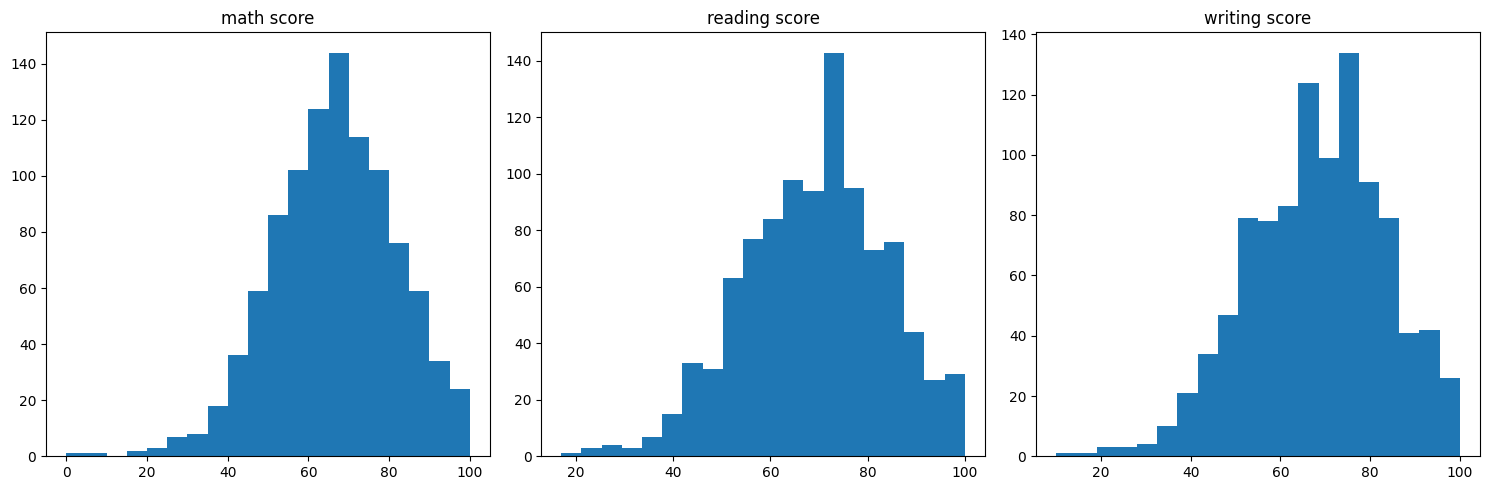

In [10]:
import matplotlib.pyplot as plt

num_cols = ['math score','reading score','writing score']

plt.figure(figsize=(15,5))
for i, col in enumerate(num_cols,1):
    plt.subplot(1,3,i)
    plt.hist(df[col], bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()


C:\Users\Bhavya\AppData\Local\Temp\ipykernel_30672\4279550716.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['math score'], df['reading score'], df['writing score']],


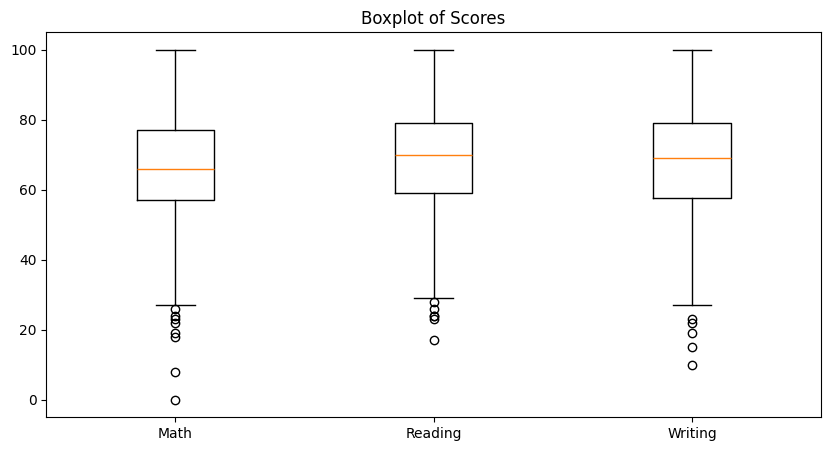

In [11]:
plt.figure(figsize=(10,5))
plt.boxplot([df['math score'], df['reading score'], df['writing score']],
            labels=['Math','Reading','Writing'])
plt.title("Boxplot of Scores")
plt.show()


In [2]:
import pandas as pd
import numpy as np
from scipy import stats

# Load dataset from GitHub
url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

print("First 5 records:")
print(df.head())

print("\nDataset Info:")
print(df.info())

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("\nNumerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

# Measures of Central Tendency
mean = df[numerical_cols].mean()
median = df[numerical_cols].median()
mode = df[numerical_cols].mode().iloc[0]

print("\nMean:\n", mean)
print("\nMedian:\n", median)
print("\nMode:\n", mode)

# Measures of Dispersion
minimum = df[numerical_cols].min()
maximum = df[numerical_cols].max()
total = df[numerical_cols].sum()
variance = df[numerical_cols].var()
std_dev = df[numerical_cols].std()

print("\nMinimum:\n", minimum)
print("\nMaximum:\n", maximum)
print("\nSum:\n", total)
print("\nVariance:\n", variance)
print("\nStandard Deviation:\n", std_dev)


First 5 records:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                      

C:\Users\Bhavya\AppData\Local\Temp\ipykernel_26992\3452248145.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

numerical_cols = df.select_dtypes(include=['int64','float64']).columns

Q1 = df[numerical_cols].quantile(0.25)
Q2 = df[numerical_cols].quantile(0.50)
Q3 = df[numerical_cols].quantile(0.75)

print("First Quartile (Q1):\n", Q1)
print("\nSecond Quartile (Q2 / Median):\n", Q2)
print("\nThird Quartile (Q3):\n", Q3)


First Quartile (Q1):
 math score       57.00
reading score    59.00
writing score    57.75
Name: 0.25, dtype: float64

Second Quartile (Q2 / Median):
 math score       66.0
reading score    70.0
writing score    69.0
Name: 0.5, dtype: float64

Third Quartile (Q3):
 math score       77.0
reading score    79.0
writing score    79.0
Name: 0.75, dtype: float64


In [5]:
import pandas as pd

url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

numerical_cols = df.select_dtypes(include=['int64','float64']).columns

correlation = df[numerical_cols].corr()
print("Correlation Matrix:\n", correlation)

covariance = df[numerical_cols].cov()
print("\nCovariance Matrix:\n", covariance)


Correlation Matrix:
                math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000

Covariance Matrix:
                math score  reading score  writing score
math score     229.918998     180.998958     184.939133
reading score  180.998958     213.165605     211.786661
writing score  184.939133     211.786661     230.907992


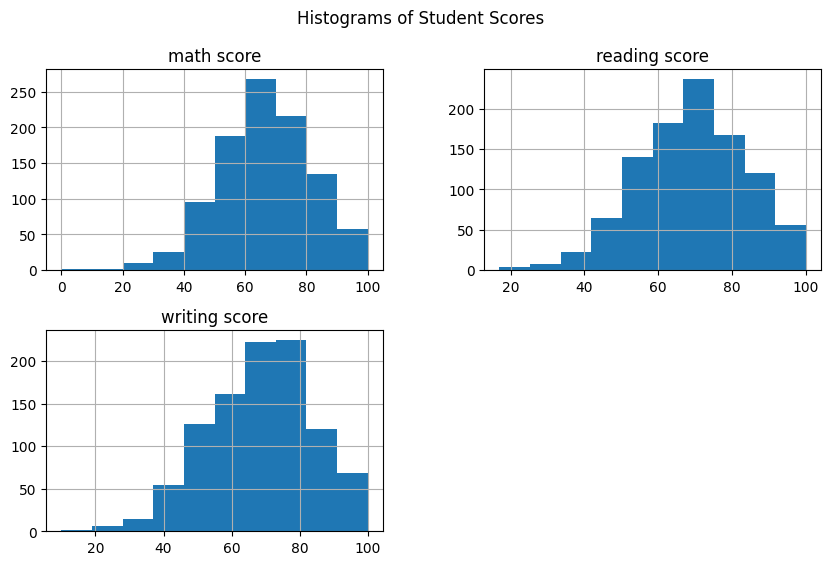

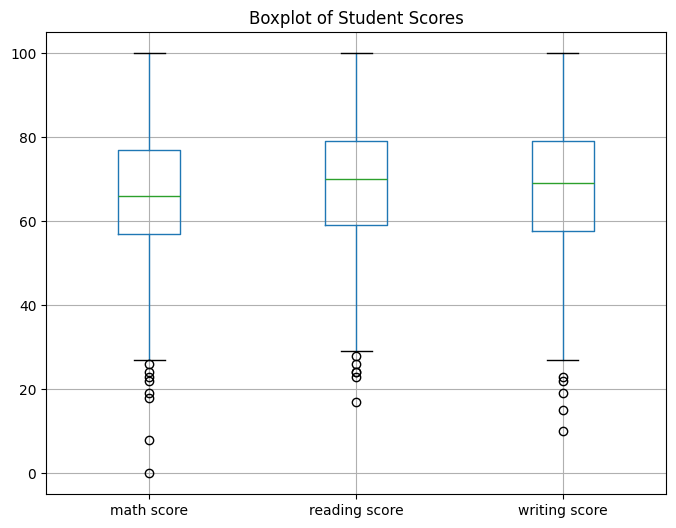

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

numerical_cols = df.select_dtypes(include=['int64','float64']).columns

# Histograms
df[numerical_cols].hist(figsize=(10,6))
plt.suptitle("Histograms of Student Scores")
plt.show()

# Boxplots
df[numerical_cols].boxplot(figsize=(8,6))
plt.title("Boxplot of Student Scores")
plt.show()
